# CodeGen0.5 - Timezone Diagnosis

Notebook ini dipakai untuk mendiagnosis interpretasi waktu `HR` pada dataset irradiance NASA per region, dimulai dari `Jawa`.

Tujuan:
- melihat pola rata-rata irradiance per `HR`
- mengecek jam puncak `CLRSKY_SFC_SW_DWN` dan `ALLSKY_SFC_SW_DWN`
- menguji hipotesis offset `UTC+7`, `UTC+8`, `UTC+9`
- membantu memutuskan apakah fitur waktu model perlu di-shift ke local time


In [8]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path('nasa_dataset_daily_20200101_20260101_representative_point_area.csv')
MISSING_SENTINEL = -999.0
TARGET_COL = 'ALLSKY_SFC_SW_DWN'
BASE_FEATURES = ['CLOUD_AMT', 'T2M', 'RH2M', 'PS', 'CLRSKY_SFC_SW_DWN']

REGION_NAME_MAP = {
    'sumatra': 'Sumatra',
    'sumatera': 'Sumatra',
    'jawa': 'Jawa',
    'kalimantan': 'Kalimantan',
    'sulawesi': 'Sulawesi',
    'nusa tenggara': 'Nusa Tenggara',
    'bali_nusa': 'Nusa Tenggara',
    'ntb_ntt': 'Nusa Tenggara',
    'maluku': 'Maluku',
    'papua': 'Papua',
}

REGION_UTC_OFFSETS = {
    'Sumatra': 7,
    'Jawa': 7,
    'Kalimantan': 8,
    'Sulawesi': 8,
    'Nusa Tenggara': 8,
    'Maluku': 9,
    'Papua': 9,
}


In [9]:
def normalize_region_name(name: str) -> str | None:
    if pd.isna(name):
        return None
    return REGION_NAME_MAP.get(str(name).strip().lower())


def load_dataset(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df['REP_NAME'] = df['REP_NAME'].map(normalize_region_name)
    df['datetime'] = pd.to_datetime(
        dict(year=df['YEAR'], month=df['MO'], day=df['DY'], hour=df['HR']),
        errors='coerce'
    )
    df = df.dropna(subset=['REP_NAME', 'datetime']).copy()

    numeric_cols = BASE_FEATURES + [TARGET_COL]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df.loc[df[col] == MISSING_SENTINEL, col] = np.nan

    return df.sort_values(['REP_NAME', 'datetime']).reset_index(drop=True)


def get_region_df(df: pd.DataFrame, region_name: str) -> pd.DataFrame:
    out = df.loc[df['REP_NAME'] == region_name].copy()
    out = out.dropna(subset=['CLRSKY_SFC_SW_DWN', TARGET_COL]).copy()
    return out.sort_values('datetime').reset_index(drop=True)


df_all = load_dataset(DATA_PATH)
print(df_all['REP_NAME'].value_counts().sort_index())


REP_NAME
Jawa             52632
Kalimantan       52632
Maluku           52632
Nusa Tenggara    52632
Papua            52632
Sulawesi         52632
Sumatra          52632
Name: count, dtype: int64


In [10]:
def summarize_hourly_pattern(region_df: pd.DataFrame, hour_col: str = 'HR') -> pd.DataFrame:
    summary = (
        region_df.groupby(hour_col)
        .agg(
            clearsky_mean=('CLRSKY_SFC_SW_DWN', 'mean'),
            allsky_mean=(TARGET_COL, 'mean'),
            clearsky_median=('CLRSKY_SFC_SW_DWN', 'median'),
            allsky_median=(TARGET_COL, 'median'),
            count=(TARGET_COL, 'size'),
        )
        .reset_index()
        .rename(columns={hour_col: 'hour'})
    )
    return summary


def add_shifted_hour(region_df: pd.DataFrame, offset_hours: int) -> pd.DataFrame:
    out = region_df.copy()
    out['shifted_hour'] = (out['HR'] + offset_hours) % 24
    return out


def score_offset(summary_df: pd.DataFrame) -> dict:
    clearsky_peak_hour = int(summary_df.loc[summary_df['clearsky_mean'].idxmax(), 'hour'])
    allsky_peak_hour = int(summary_df.loc[summary_df['allsky_mean'].idxmax(), 'hour'])
    daylight_hours = summary_df.loc[summary_df['clearsky_mean'] > 10, 'hour'].tolist()

    if daylight_hours:
        sunrise_hour = int(min(daylight_hours))
        sunset_hour = int(max(daylight_hours))
    else:
        sunrise_hour = None
        sunset_hour = None

    peak_distance_from_noon = abs(clearsky_peak_hour - 12)
    score = peak_distance_from_noon

    if sunrise_hour is not None and sunrise_hour < 4:
        score += 2
    if sunset_hour is not None and sunset_hour > 20:
        score += 2

    return {
        'clearsky_peak_hour': clearsky_peak_hour,
        'allsky_peak_hour': allsky_peak_hour,
        'sunrise_hour_est': sunrise_hour,
        'sunset_hour_est': sunset_hour,
        'score': score,
    }


def run_timezone_diagnosis(region_name: str = 'Jawa'):
    region_df = get_region_df(df_all, region_name)
    offset_candidates = [0, 7, 8, 9]
    rows = []

    for offset in offset_candidates:
        shifted_df = add_shifted_hour(region_df, offset)
        summary = summarize_hourly_pattern(shifted_df, hour_col='shifted_hour')
        offset_score = score_offset(summary)
        offset_score['offset_hours'] = offset
        rows.append(offset_score)

    diagnosis_df = pd.DataFrame(rows).sort_values('score').reset_index(drop=True)
    return region_df, diagnosis_df


In [11]:
region_name = 'Jawa'
region_df, diagnosis_df = run_timezone_diagnosis(region_name)
diagnosis_df


,clearsky_peak_hour,allsky_peak_hour,sunrise_hour_est,sunset_hour_est,score,offset_hours
0,12,12,7,18,0,8
1,11,11,6,17,1,7
2,13,13,8,19,1,9
3,4,4,0,23,12,0


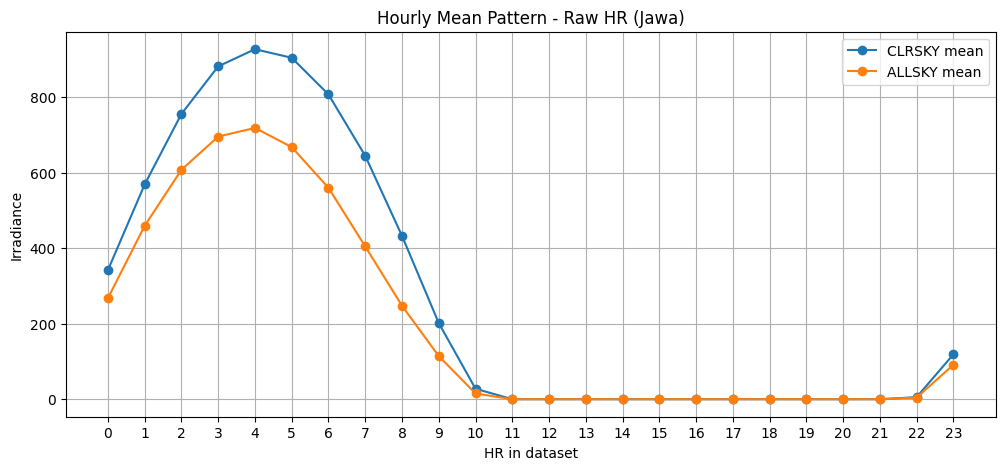

,hour,clearsky_mean,allsky_mean,clearsky_median,allsky_median,count
0,0,342.130242,267.665182,336.790,266.365,2192
1,1,569.181373,459.613659,576.975,470.400,2192
2,2,755.947308,607.925420,776.060,625.340,2192
3,3,881.991286,695.933362,911.975,715.600,2192
4,4,927.401291,718.854494,955.400,733.250,2192
5,5,904.734717,668.034918,927.650,680.830,2192
6,6,807.581524,560.204320,819.565,574.550,2192
7,7,644.918823,404.781332,644.830,418.660,2192
8,8,432.872454,247.587888,423.560,256.760,2192
9,9,201.828891,114.281045,187.400,113.190,2192


In [12]:
raw_summary = summarize_hourly_pattern(region_df, hour_col='HR')

plt.figure(figsize=(12, 5))
plt.plot(raw_summary['hour'], raw_summary['clearsky_mean'], marker='o', label='CLRSKY mean')
plt.plot(raw_summary['hour'], raw_summary['allsky_mean'], marker='o', label='ALLSKY mean')
plt.title(f'Hourly Mean Pattern - Raw HR ({region_name})')
plt.xlabel('HR in dataset')
plt.ylabel('Irradiance')
plt.xticks(range(24))
plt.grid(True)
plt.legend()
plt.show()

raw_summary


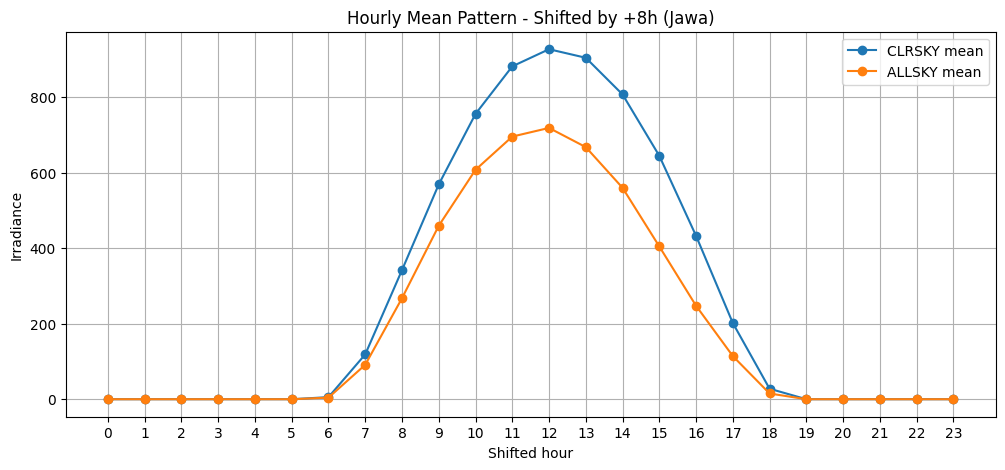

,hour,clearsky_mean,allsky_mean,clearsky_median,allsky_median,count
0,0,0.000000,0.000000,0.000,0.000,2192
1,1,0.000000,0.000000,0.000,0.000,2192
2,2,0.000000,0.000000,0.000,0.000,2192
3,3,0.000000,0.000000,0.000,0.000,2192
4,4,0.000000,0.000000,0.000,0.000,2192
5,5,0.000000,0.000000,0.000,0.000,2192
6,6,5.504781,4.228344,0.000,0.000,2192
7,7,118.799516,91.240114,106.720,84.915,2192
8,8,342.130242,267.665182,336.790,266.365,2192
9,9,569.181373,459.613659,576.975,470.400,2192


In [13]:
best_offset = int(diagnosis_df.iloc[0]['offset_hours'])
shifted_df = add_shifted_hour(region_df, best_offset)
shifted_summary = summarize_hourly_pattern(shifted_df, hour_col='shifted_hour')

plt.figure(figsize=(12, 5))
plt.plot(shifted_summary['hour'], shifted_summary['clearsky_mean'], marker='o', label='CLRSKY mean')
plt.plot(shifted_summary['hour'], shifted_summary['allsky_mean'], marker='o', label='ALLSKY mean')
plt.title(f'Hourly Mean Pattern - Shifted by +{best_offset}h ({region_name})')
plt.xlabel('Shifted hour')
plt.ylabel('Irradiance')
plt.xticks(range(24))
plt.grid(True)
plt.legend()
plt.show()

shifted_summary


In [14]:
all_regions_rows = []
for region_name in sorted(REGION_UTC_OFFSETS.keys()):
    _, diag_df = run_timezone_diagnosis(region_name)
    best_row = diag_df.iloc[0].to_dict()
    best_row['region_name'] = region_name
    best_row['expected_local_offset'] = REGION_UTC_OFFSETS[region_name]
    all_regions_rows.append(best_row)

all_regions_diag = pd.DataFrame(all_regions_rows)
all_regions_diag = all_regions_diag[[
    'region_name', 'offset_hours', 'expected_local_offset',
    'clearsky_peak_hour', 'allsky_peak_hour',
    'sunrise_hour_est', 'sunset_hour_est', 'score'
]].sort_values('region_name').reset_index(drop=True)
all_regions_diag


,region_name,offset_hours,expected_local_offset,clearsky_peak_hour,allsky_peak_hour,sunrise_hour_est,sunset_hour_est,score
0,Jawa,8,7,12,12,7,18,0
1,Kalimantan,8,8,12,12,6,17,0
2,Maluku,9,9,12,12,6,18,0
3,Nusa Tenggara,9,8,12,12,7,18,0
4,Papua,9,9,11,11,6,17,1
5,Sulawesi,9,8,12,12,7,18,0
6,Sumatra,7,7,12,12,6,17,0


## Cara membaca hasil

- Jika offset terbaik `Jawa` mendekati `+7`, itu mendukung hipotesis bahwa `HR` dataset kemungkinan berada pada basis `UTC`.
- Jika `Sulawesi` / `Nusa Tenggara` terbaik di `+8`, dan `Papua` / `Maluku` terbaik di `+9`, hipotesis `UTC` makin kuat.
- Jika offset terbaik justru `0`, berarti ada kemungkinan `HR` sudah berada pada local time atau local solar time.

Langkah berikutnya setelah diagnosis ini adalah mengubah pipeline training agar fitur waktu mengikuti offset region yang paling masuk akal.